# 03 · Model Training + Results

**When to run this notebook:** whenever you add or change a model, to produce a
full training run across all model families and evaluate it on the locked
holdout.

## Business framing

We are solving a **supervised binary classification** problem: will a video beat
its channel's own 7-day median engagement, using only upload/24h signals? The
target is naturally ~50/50 by design, so the comparison across models is about
ranking quality and error trade-offs, not class imbalance.

This notebook:
1. trains **all** model families on the most recent committed data snapshot
   (Logistic Regression L1, Random Forest, XGBoost, and an RF+XGB ensemble);
2. analyzes the train / test / validation splits;
3. evaluates on the **locked validation holdout** and compares train/test/val;
4. runs a **segment audit** to surface per-vertical / per-tier blind spots;
5. places the run in the context of the full model-version history.

> **Sequence:** notebook 3 of 5. See [notebooks.md](./notebooks.md).

## Configuration

By **default** this notebook reuses the most recent committed raw snapshot from
GCS — *no BigQuery call* — so you can iterate on training without re-pulling
data. To include a **fresh data pull**, comment out the default config block and
uncomment the alternate block; the training and evaluation steps below are
**identical** in either case (both scenarios expose the same stage set).

`DRY_RUN=True` (default) means no model artifacts, snapshots, or version bumps
are written.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda
from utils.snapshot_model import ModelResult, ModelType
from evaluation.segment_auditor import SegmentAuditor
from dataclasses import asdict

IMAGES_FOLDER = "../../../images/results/"
DRY_RUN = True

# DRY_RUN doubles as the figure-write guard: in a dry run we pass save_figure_name=None
# so no image files are written to disk; flip DRY_RUN to False to persist figures.
def fig_path(name):
    return None if DRY_RUN else f"{IMAGES_FOLDER}{name}"

# Metric column order used in every results table below. Global (macro) metrics
# come first, then the per-class above/below breakdown.
#   *_macro = sklearn average="macro" = unweighted mean of above- and below-baseline
#             scores. It is the single "overall" number that weights both classes equally.
METRIC_COLS = [
    "roc_auc", "accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_above", "recall_above", "f1_above",
    "precision_below", "recall_below", "f1_below",
]

In [ ]:
# ---- DEFAULT: retrain on the most recent committed snapshot (reads GCS, no BQ) ----
# snapshot_models() is only added when DRY_RUN=False so no version bump appears
# during dry runs.
builder = VersionConfig.load(use_synthetic=False)
if not DRY_RUN:
    builder = builder.snapshot_models()
config = builder.dry_run(DRY_RUN).build()
stages = PipelineFactory.retrain_existing_data(config)

# ---- ALTERNATE: pull a fresh data snapshot from BigQuery, then train -------------
# Uncomment this block AND comment out the default block above to include new data.
# Everything downstream is identical. See notebooks.md for the full new-data workflow.
# config = (
#     VersionConfig.load(use_synthetic=False)
#     .snapshot_raw()             # new BQ pull -> data minor bump + baselines bump
#     .snapshot_final()           # persist engineered splits
#     .snapshot_models_new_data() # model MAJOR bump (retrained on new data)
#     .dry_run(DRY_RUN)
#     .build()
# )
# stages = PipelineFactory.full_run(config)

run = PipelineRun(config)
print("Scenario:", stages.scenario)

### Pipeline execution — through scaling

The stage calls below are the same regardless of whether new data was pulled. In
the default (reuse) scenario `RawSnapshotter` is a no-op; in the new-data
scenario it writes the fresh snapshot (when `DRY_RUN=False`).

In [3]:
stages.loader.run(run)
stages.raw_snapshotter.run(run)   # writes only in the new-data scenario (and when DRY_RUN=False)
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)
run.summary()

Loaded snapshot 'v3.4_real': 60696 rows from 2026-04-29
  Polls: {'upload': 21398, '24h': 20906, '7d': 18392}
Loaded baselines 'v4.0': 28814 baseline videos, 974 median rows (974 channels)
[dry_run] RawSnapshotter — GCS write skipped.
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 18334 (dropped 3111 incomplete)
  Pivoted shape: (18403, 34)

[2/3] Joining baseline medians...
  Baseline join: 18403/18403 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/faile

## Analysis of the train / test / validation sets

Before training, confirm the three partitions are representative. The validation
holdout is **locked** (fixed video IDs in GCS); train/test are re-split 80/20
from the remaining pool on each run, stratified on the 18-cell key so class
balance and segment mix stay consistent across splits.

In [4]:
# Sizes and class balance per split.
split_rows = []
for name, dfs in [("train", run.df_train), ("test", run.df_test), ("val", run.df_val)]:
    split_rows.append({
        "split": name,
        "rows": len(dfs),
        "pct_of_total": round(len(dfs) / (len(run.df_train) + len(run.df_test) + len(run.df_val)) * 100, 1),
        "pct_above_baseline": round(dfs["above_baseline"].mean(), 3),
    })
df_splits = pd.DataFrame(split_rows).set_index("split")
print(df_splits.to_string())

        rows  pct_of_total  pct_above_baseline
split                                         
train  10235          56.9               0.549
test    2559          14.2               0.549
val     5192          28.9               0.555


Vertical share by split:
           train   test    val
vertical                      
Tech       0.345  0.345  0.189
Lifestyle  0.344  0.344  0.637
Education  0.312  0.311  0.174


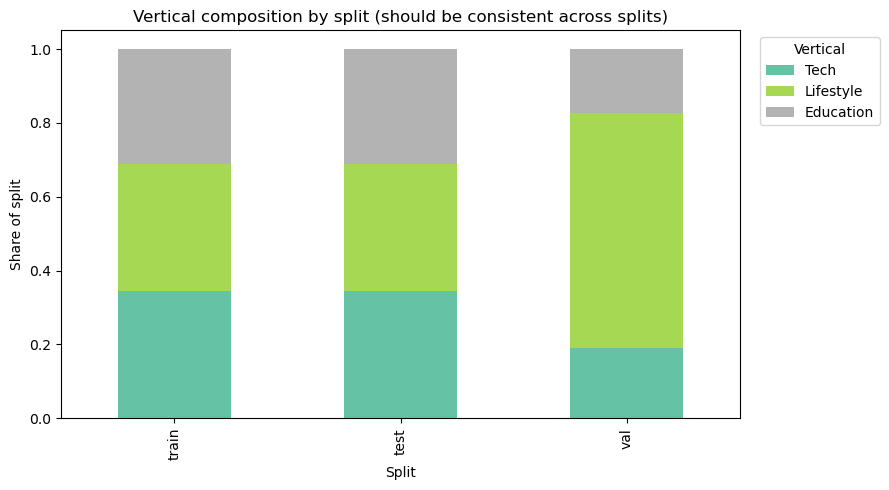

In [5]:
# Segment representation across splits (vertical x tier), merged back from df_clean.
labels = run.df_clean[["video_id", "vertical", "tier"]]
seg_frames = []
for name, dfs in [("train", run.df_train), ("test", run.df_test), ("val", run.df_val)]:
    merged = dfs[["video_id"]].merge(labels, on="video_id", how="left")
    share = merged["vertical"].value_counts(normalize=True).rename(name)
    seg_frames.append(share)
df_vertical_mix = pd.concat(seg_frames, axis=1).round(3)
print("Vertical share by split:")
print(df_vertical_mix.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
df_vertical_mix.T.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Vertical composition by split (should be consistent across splits)")
ax.set_ylabel("Share of split")
ax.set_xlabel("Split")
ax.legend(title="Vertical", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
if not DRY_RUN:
    plt.savefig(f"{IMAGES_FOLDER}03_split_vertical_mix.png")
plt.show()

## Train all models

`ModelTrainer` trains Logistic Regression (L1), Random Forest, XGBoost, and the
soft-voting RF+XGB ensemble using the hyperparameters from the current GCS
snapshot, then evaluates each on the **test** split. Hyperparameter search is
*not* run here — that is the job of notebook 04. Cross-validation underlies the
tuned parameters loaded from the hyperparameter snapshot.

In [6]:
stages.trainer.run(run)
run.summary()

Loaded hyperparams 'v1.1' (saved 2026-04-29)
  Models: ['LogisticRegression', 'RandomForest', 'XGBoost', 'VotingClassifier']
  Search: {'strategy': 'random', 'n_iter': 100, 'cv': 5, 'scoring': 'roc_auc'}
Loaded hyperparams from snapshot 'v1.1'.
  Note: injected l1_ratio=0.5 for elasticnet LR (missing from snapshot).
Training LogisticRegression (L1)...
Training RandomForestClassifier...
Training XGBClassifier...
Training VotingClassifier ensemble (RF + XGB, weights=[1, 2])...

=== ModelTrainer — test-set results ===
  lr_l1         AUC=0.7706  acc=0.7100  F1↑=0.7431
  rf            AUC=0.8646  acc=0.7835  F1↑=0.8112
  xgb           AUC=0.9088  acc=0.8249  F1↑=0.8442
  ensemble      AUC=0.9043  acc=0.8238  F1↑=0.8441
PipelineRun(config=VersionConfig(data=(3, 4), model=(5, 4), baselines=(4, 0), hyperparams=(1, 1), use_synthetic=False, active=['models']))
  df_videos      populated  DataFrame shape=(60696, 23)
  df_baselines   populated  DataFrame shape=(28814, 15)
  df_medians     populat

### (Optional) persist artifacts

With `DRY_RUN=False`, snapshot the engineered splits and the trained models to
GCS. Both are no-ops in a dry run.

In [7]:
stages.final_snapshotter.run(run)
stages.model_snapshotter.run(run)

[dry_run] FinalSnapshotter — GCS write skipped.
[dry_run] ModelSnapshotter — GCS write skipped.


PipelineRun(model_version='v5.3', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models'])

## Evaluate on the locked validation holdout

`Validator` scores each model on the locked holdout using each model's own saved
scaler, then `ValidationResultsSnapshotter` appends the run to the JSONL history
(skipped under `DRY_RUN`).

In [8]:
stages.validator.run(run)
stages.validation_results_snapshotter.run(run)


=== Validator — validation-set results ===
  lr_l1           AUC=0.7678  acc=0.6997  F1↑=0.7321
  rf              AUC=0.8716  acc=0.7947  F1↑=0.8223
  xgb             AUC=0.9085  acc=0.8267  F1↑=0.8458
  ensemble        AUC=0.9053  acc=0.8297  F1↑=0.8486
[dry_run] ValidationResultsSnapshotter — GCS append skipped.


PipelineRun(model_version='v5.3', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])

### A note on the evaluation metrics

Every metrics table in this notebook leads with three **global** scores —
`precision_macro`, `recall_macro`, `f1_macro` — followed by the per-class
breakdown (`*_above`, `*_below`).

The global scores use **sklearn's `average="macro"`**: compute precision /
recall / F1 separately for each class, then take the unweighted mean across
classes. For example, `f1_macro = mean(f1_above, f1_below)`. Because the
target is ~50/50 by design, macro and weighted averages are nearly identical
here — macro is preferred because it treats both classes equally regardless
of exact counts, which matches the intent of a balanced binary target.

The per-class split is retained because the error costs differ — a false
"will overperform" prediction has a different business impact than a false
"will underperform" — but the macro scores are shown first as the headline
numbers.

### Evaluation metric — choice & rationale

The **primary metric is ROC-AUC**: it measures how well a model ranks
above-baseline videos above below-baseline ones across *all* thresholds, which
matches the use case (flagging likely under/over-performers early, where the
decision threshold may be tuned later). Because the classes are ~balanced,
**accuracy** is also meaningful, and **macro F1** gives a single
threshold-dependent summary. ROC-AUC is the metric we select models on.

In [9]:
df_val = pd.DataFrame(run.results).T[METRIC_COLS].astype(float).round(4)
df_val.index.name = "model"
df_val.style.highlight_max(color="#d4edda").format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
lr_l1,0.7678,0.6997,0.6958,0.6949,0.6953,0.7257,0.7386,0.7321,0.6659,0.6512,0.6585
rf,0.8716,0.7947,0.7954,0.7871,0.7896,0.7919,0.8551,0.8223,0.7988,0.7192,0.7570
xgb,0.9085,0.8267,0.8252,0.8230,0.8239,0.8360,0.8558,0.8458,0.8143,0.7903,0.8021
ensemble,0.9053,0.8297,0.8283,0.8261,0.8271,0.8385,0.8589,0.8486,0.8181,0.7933,0.8055


## Train vs. test vs. validation

To diagnose overfitting we score every model on the **training** split too, then
compare train / test / validation side by side. A large train→validation gap
means the model is memorizing the training data; a small gap with high
validation AUC is what we want.

The plot below shows ROC-AUC per model with the train−validation gap annotated
above each group (the chosen format: a single AUC-focused grouped bar with gap
labels). The full multi-metric table follows.

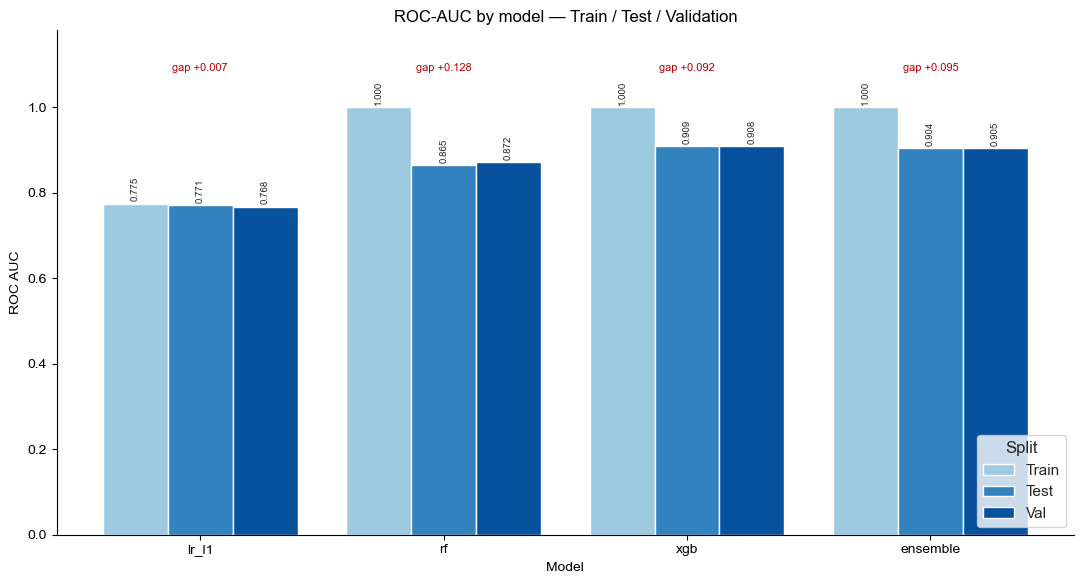

In [10]:
# Score every trained model on the train / test / validation splits.
train_results = {
    name: asdict(ModelResult.from_sklearn(
        entry["model"], run.X_train, run.y_train, run.X_train.columns.tolist()))
    for name, entry in run.models.items()
}
test_results = {name: asdict(entry["result"]) for name, entry in run.models.items()}
val_results = run.results

results_by_split = {"train": train_results, "test": test_results, "val": val_results}

eda.plot_split_comparison(
    results_by_split,
    metric="roc_auc",
    title="ROC-AUC by model — Train / Test / Validation",
    save_figure_name=fig_path("03_train_test_val_auc.png"),
)

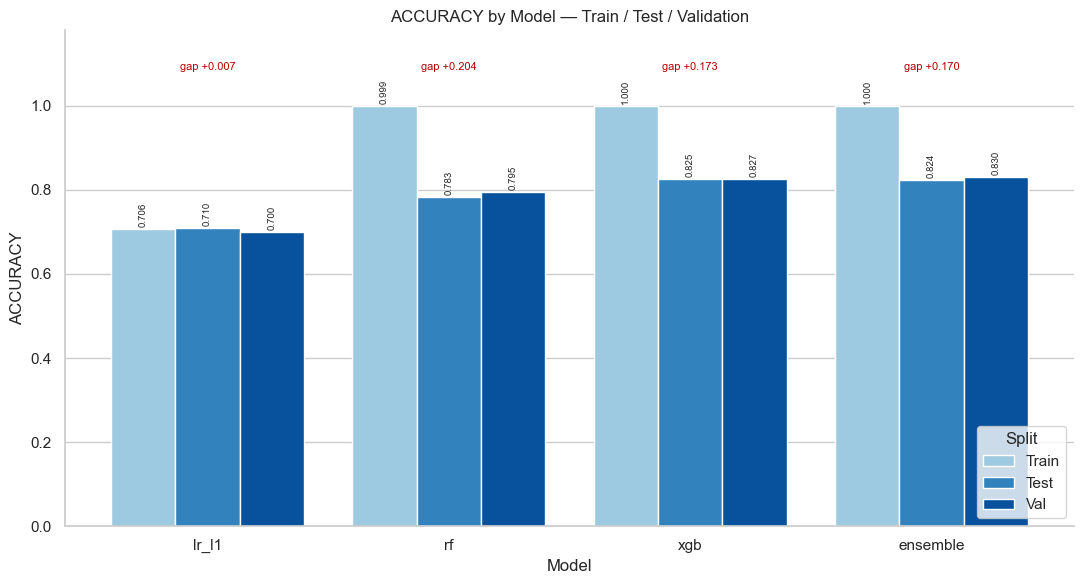

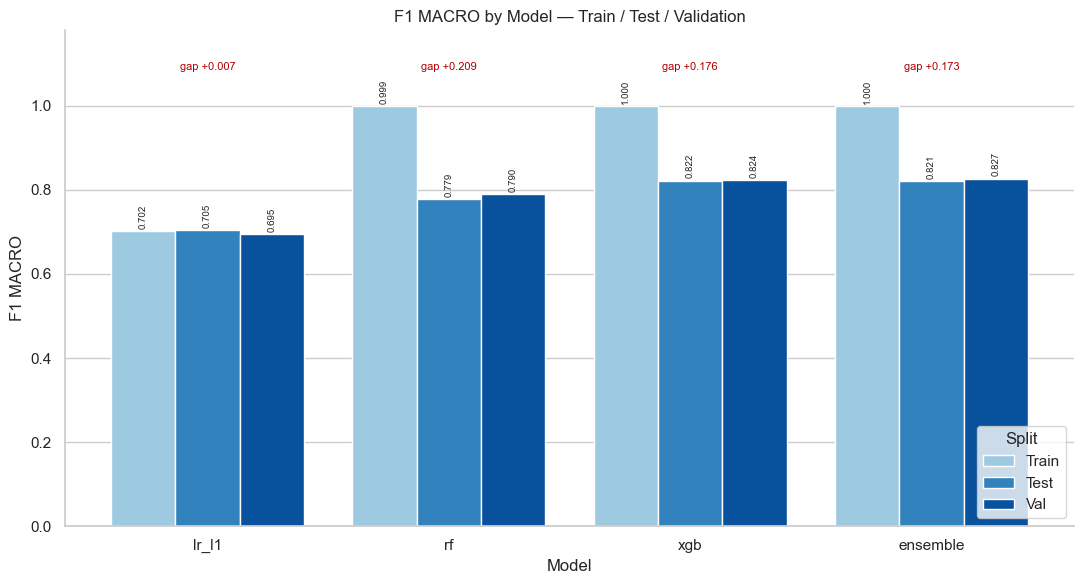

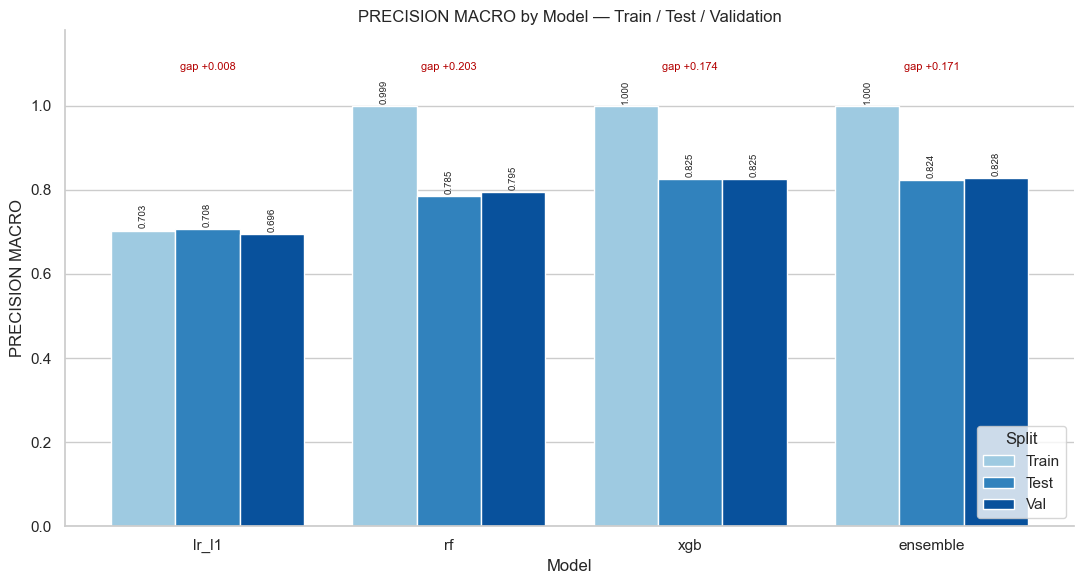

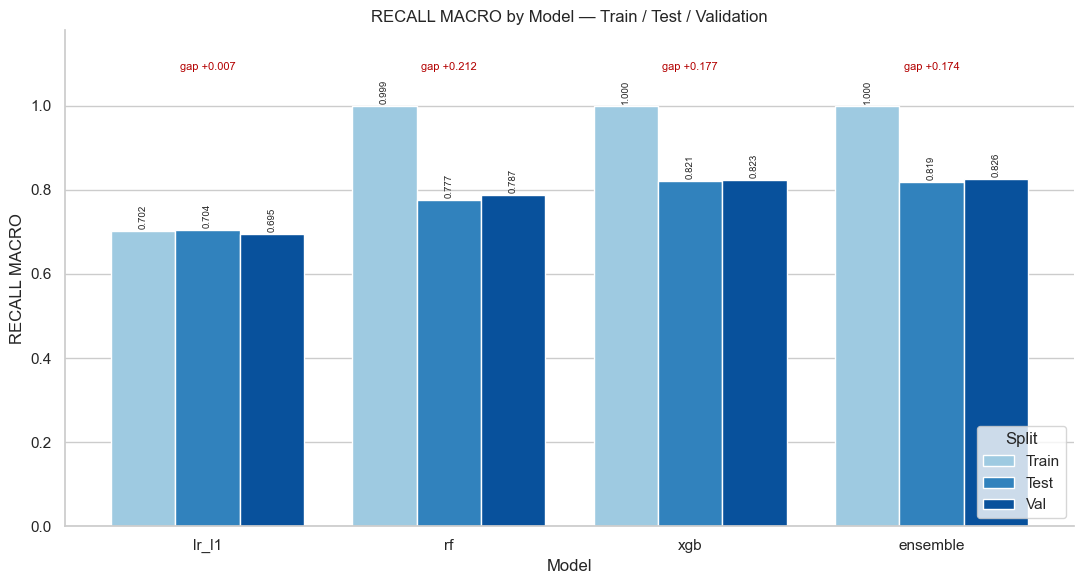

In [11]:
# Accuracy, macro F1, macro Precision, macro Recall — same split view.
for metric, fname in [
    ("accuracy",        "03_train_test_val_accuracy.png"),
    ("f1_macro",        "03_train_test_val_f1.png"),
    ("precision_macro", "03_train_test_val_precision.png"),
    ("recall_macro",    "03_train_test_val_recall.png"),
]:
    eda.plot_split_comparison(
        results_by_split,
        metric=metric,
        save_figure_name=fig_path(fname),
    )

In [12]:
# Full 3-way table (global macro metrics first, then per-class).
records = {}
for name in run.models:
    records[(name, "train")] = {m: train_results[name].get(m) for m in METRIC_COLS}
    records[(name, "test")] = {m: test_results[name].get(m) for m in METRIC_COLS}
    records[(name, "val")] = {m: val_results[name].get(m) for m in METRIC_COLS}

df_3way = pd.DataFrame(records).T.astype(float).round(4)
df_3way.index.names = ["model", "split"]
df_3way

roc_auc  accuracy  precision_macro  recall_macro  f1_macro  \
model    split                                                               
lr_l1    train   0.7749    0.7063           0.7034        0.7018    0.7024   
         test    0.7706    0.7100           0.7075        0.7042    0.7052   
         val     0.7678    0.6997           0.6958        0.6949    0.6953   
rf       train   1.0000    0.9987           0.9987        0.9987    0.9987   
         test    0.8646    0.7835           0.7848        0.7766    0.7788   
         val     0.8716    0.7947           0.7954        0.7871    0.7896   
xgb      train   1.0000    0.9996           0.9996        0.9996    0.9996   
         test    0.9088    0.8249           0.8249        0.8207    0.8222   
         val     0.9085    0.8267           0.8252        0.8230    0.8239   
ensemble train   1.0000    0.9996           0.9996        0.9996    0.9996   
         test    0.9043    0.8238           0.8244        0.8188    0.8207   
         val     0.9053    0.8297           0.8283        0.8261    0.8271   

                precision_above  recall_above  f1_above  precision_below  \
model    split                                                             
lr_l1    train           0.7257        0.7479    0.7366           0.6811   
         test            0.7235        0.7637    0.7431           0.6914   
         val             0.7257        0.7386    0.7321           0.6659   
rf       train           0.9988        0.9989    0.9988           0.9987   
         test            0.7783        0.8470    0.8112           0.7913   
         val             0.7919        0.8551    0.8223           0.7988   
xgb      train           0.9996        0.9996    0.9996           0.9996   
         test            0.8253        0.8641    0.8442           0.8244   
         val             0.8360        0.8558    0.8458           0.8143   
ensemble train           0.9996        0.9996    0.9996           0.9996   
         test            0.8206        0.8690    0.8441           0.8282   
         val             0.8385        0.8589    0.8486           0.8181   

                recall_below  f1_below  
model    split                          
lr_l1    train        0.6557    0.6681  
         test         0.6447    0.6673  
         val          0.6512    0.6585  
rf       train        0.9985    0.9986  
         test         0.7062    0.7463  
         val          0.7192    0.7570  
xgb      train        0.9996    0.9996  
         test         0.7773    0.8002  
         val          0.7903    0.8021  
ensemble train        0.9996    0.9996  
         test         0.7686    0.7973  
         val          0.7933    0.8055

## Segment audit

A single global model can hide blind spots: it may rank well overall yet
underperform on a specific vertical or channel tier. `SegmentAuditor` evaluates
each model on per-vertical and per-tier slices of the validation set and flags
segments whose ROC-AUC drops materially below the global figure. This directly
informs final model selection (notebook 05) and whether segment-specific models
are worth exploring.

In [13]:
# df_val retains the vertical/tier string columns; merge them back defensively
# in case a future engineering change drops them.
df_val_seg = run.df_val
if "vertical" not in df_val_seg.columns or "tier" not in df_val_seg.columns:
    df_val_seg = df_val_seg.merge(
        run.df_clean[["video_id", "vertical", "tier"]], on="video_id", how="left"
    )

auditor = SegmentAuditor(
    models=run.models,
    X_val=run.X_val,      # scaled with this run's scaler — matches freshly trained models
    y_val=run.y_val,
    df_val=df_val_seg,
    threshold=0.5,        # default operating threshold; a sweep is future work
)
segment_results = auditor.audit()
auditor.print_summary(segment_results)


  Segment audit — VERTICAL
vertical      ensemble  auc    lr_l1  auc    rf  auc    xgb  auc    ensemble  acc    lr_l1  acc    rf  acc    xgb  acc
----------  ---------------  ------------  ---------  ----------  ---------------  ------------  ---------  ----------
Education            0.9010        0.7740     0.8740      0.9035           0.8283        0.7100     0.8058      0.8220
Lifestyle            0.9251        0.7694     0.8901      0.9297           0.8531        0.7122     0.8079      0.8498
Tech                 0.8868        0.7588     0.8475      0.8898           0.8065        0.6772     0.7705      0.8065
ALL                  0.9053        0.7678     0.8716      0.9085           0.8297        0.6997     0.7947      0.8267

  Blind spots (roc_auc > 0.03 below global):
    None — model performs uniformly across all segments.

  Segment audit — TIER
tier      ensemble  auc    lr_l1  auc    rf  auc    xgb  auc    ensemble  acc    lr_l1  acc    rf  acc    xgb  acc
------  --------

## Feature importance

What is each model relying on? For the tree models this is impurity-reduction
importance; for Logistic Regression it is the (signed) coefficient. The patterns
here corroborate the project thesis that *channel-relative, contextual* signals
(normalized rates, baseline comparisons, tier, content format) outrank absolute
counts.

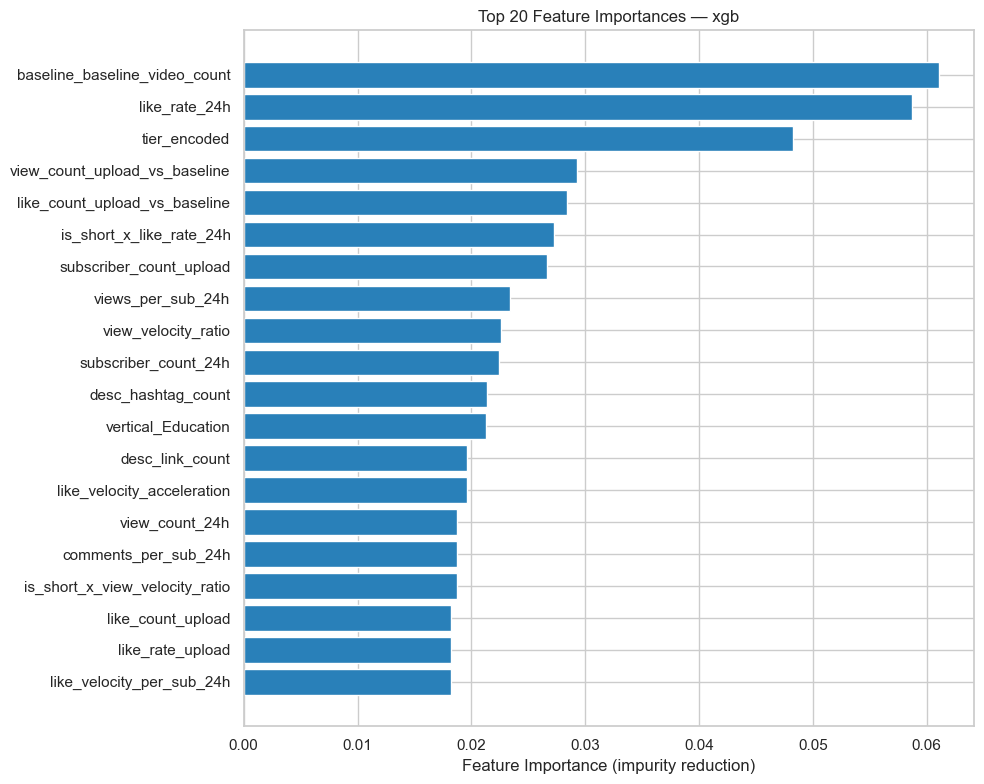


lr_l1:
  like_count_upload_vs_baseline        +12.8392
  view_count_upload_vs_baseline        -4.0572
  like_rate_24h                        +1.1703
  view_count_velocity_24h              -0.7846
  like_count_velocity_24h              +0.5275

rf:
  like_rate_24h                        +0.0981
  view_velocity_ratio                  +0.0458
  like_count_upload_vs_baseline        +0.0390
  like_rate_upload                     +0.0378
  view_count_upload_vs_baseline        +0.0309

xgb:
  baseline_baseline_video_count        +0.0611
  like_rate_24h                        +0.0587
  tier_encoded                         +0.0482
  view_count_upload_vs_baseline        +0.0293
  like_count_upload_vs_baseline        +0.0284

ensemble:


In [14]:
eda.plot_feature_importance(run, model_name="xgb", top_n=20, save_figure_name=fig_path("03_feature_importance_xgb.png"))

for name, entry in run.results.items():
    top = entry.get("top_features", [])[:5]
    print(f"\n{name}:")
    for f in top:
        key = "coefficient" if "coefficient" in f else "importance"
        print(f"  {f['feature']:35s}  {f[key]:+.4f}")

## Cross-version context

Where does this run sit in the project's history? The trajectory plots below load
every saved model snapshot from GCS and chart metric progression across model
generations. The dashed vertical line marks the methodology change at v4.0, when
a locked holdout replaced per-run test sets — comparisons across that line are
directional, not apples-to-apples. (These plots also appear, focused on the
final model, in notebook 05.)

In [15]:
eda.load_model_comparison(run)

Loaded 33 model snapshots


,model_type,data_snapshot,training_date,real_rows,synth_rows,accuracy,roc_auc,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
version,,,,,,,,,,,,,,,,
v1.0_lr_l1,LogisticRegression,v1.0_model_mixed66,2026-03-26,2100,5000,0.6305,0.6258,0.6258,0.6036,0.5981,0.6366,0.8081,0.7122,0.6149,0.3991,0.4840
v1.0_rf,RandomForest,v1.0_model_mixed66,2026-03-26,2100,5000,0.6952,0.7595,0.6898,0.6848,0.6862,0.7161,0.7643,0.7394,0.6635,0.6053,0.6330
v1.0_xgb,XGBoost,v1.0_model_mixed66,2026-03-26,2100,5000,0.7105,0.7703,0.7066,0.7089,0.7072,0.7562,0.7205,0.7379,0.6570,0.6974,0.6766
v2.0_lr_l1,LogisticRegression,v2.0_mixed_70real,2026-03-26,3255,1743,0.6229,0.6464,0.6153,0.6017,0.5988,0.6360,0.7707,0.6969,0.5946,0.4326,0.5008
v2.0_rf,RandomForest,v2.0_mixed_70real,2026-03-26,3255,1743,0.7334,0.7966,0.7339,0.7197,0.7223,0.7322,0.8297,0.7779,0.7356,0.6096,0.6667
v2.0_xgb,XGBoost,v2.0_mixed_70real,2026-03-26,3255,1743,0.7297,0.7971,0.7267,0.7198,0.7218,0.7409,0.7991,0.7689,0.7125,0.6404,0.6746
v3.0_lr_l1,LogisticRegression,v3.0_mixed_80real,2026-03-28,4037,1261,0.6406,0.6557,0.6399,0.6169,0.6123,0.6416,0.8127,0.7171,0.6382,0.4212,0.5075
v3.0_rf,RandomForest,v3.0_mixed_80real,2026-03-28,4037,1261,0.7604,0.8246,0.7614,0.7491,0.7520,0.7571,0.8428,0.7977,0.7658,0.6554,0.7063
v3.0_xgb,XGBoost,v3.0_mixed_80real,2026-03-28,4037,1261,0.7624,0.8303,0.7592,0.7567,0.7577,0.7791,0.8039,0.7913,0.7394,0.7095,0.7241


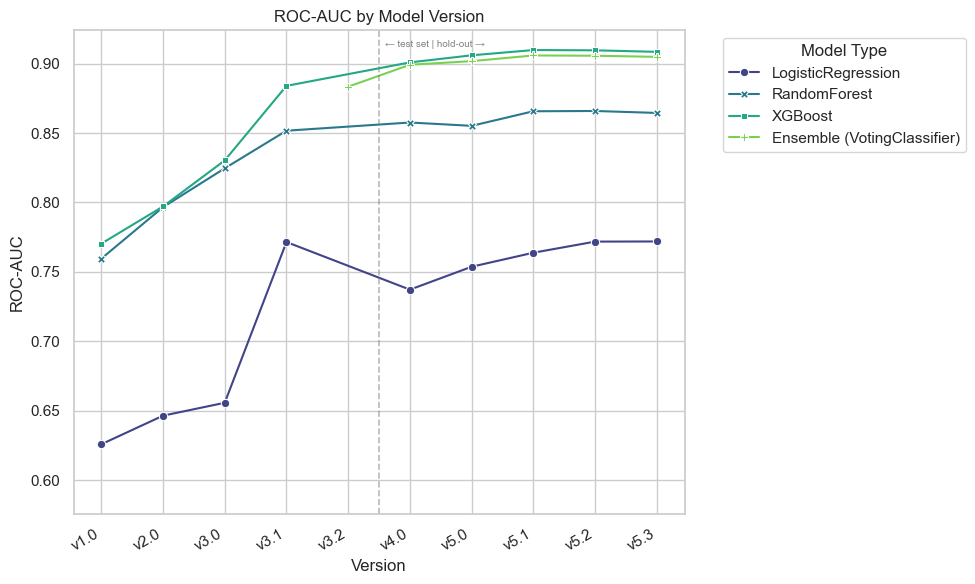

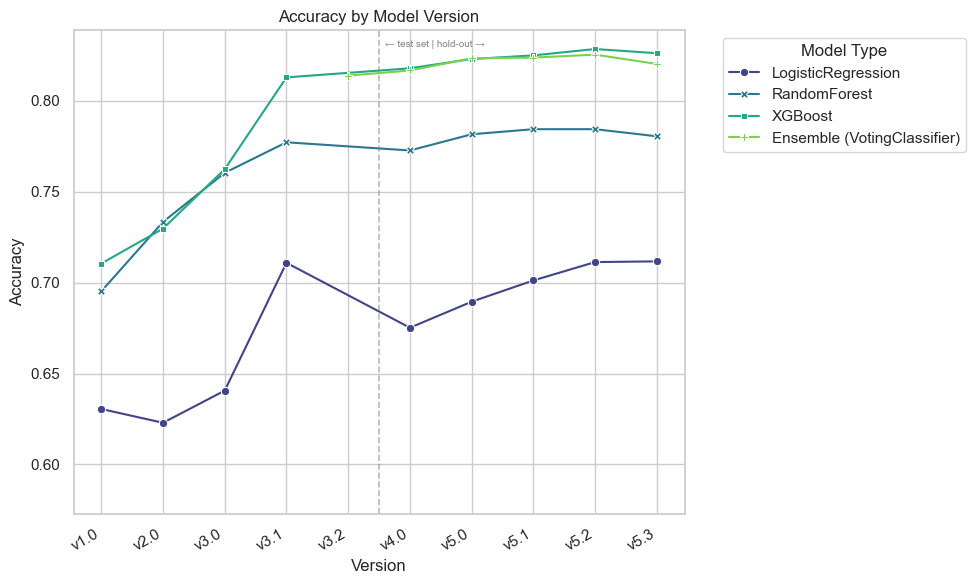

In [16]:
eda.plot_roc_auc(run, save_figure_name=fig_path("roc_auc_by_version_line.png"))
eda.plot_accuracy(run, save_figure_name=fig_path("accuracy_by_model.png"))

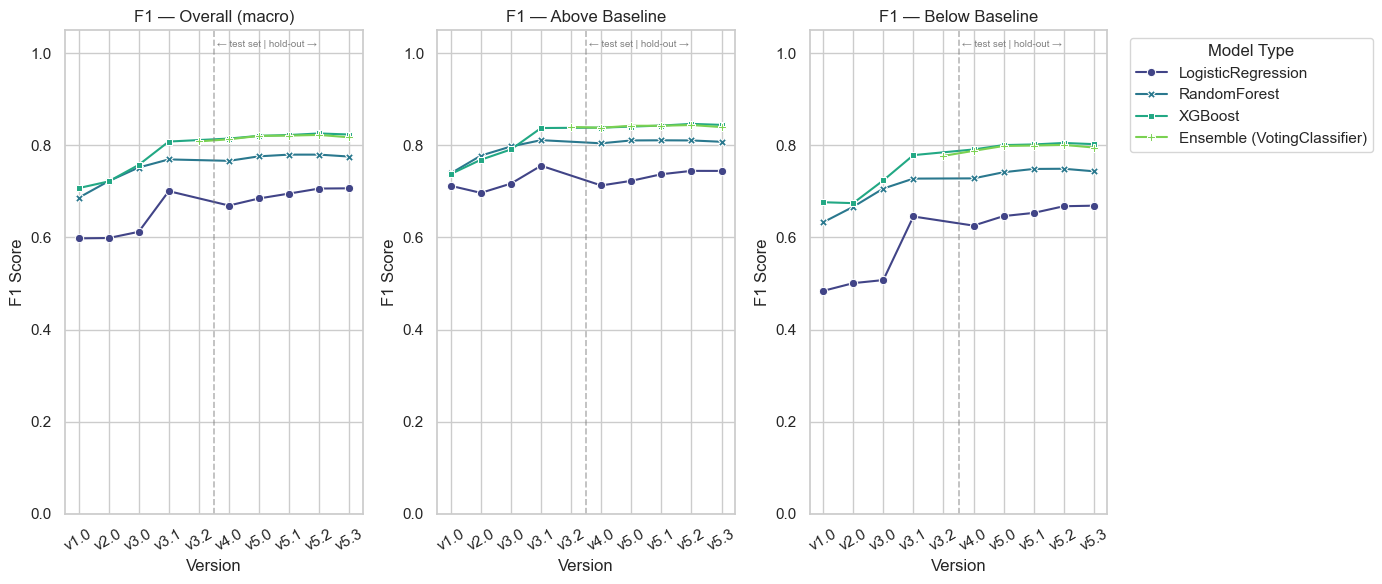

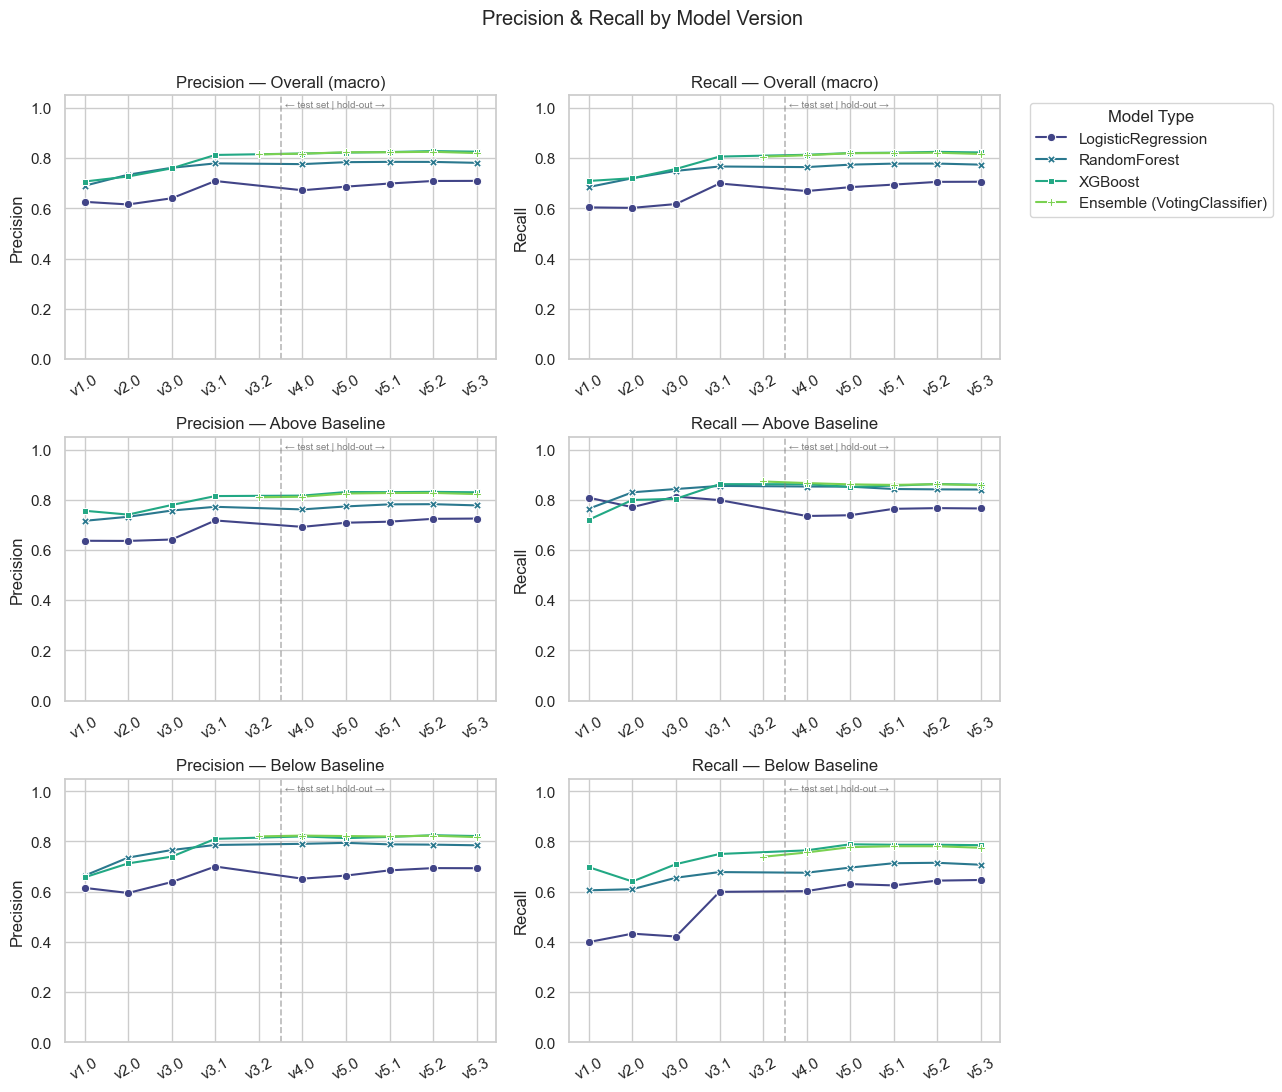

In [17]:
# F1 and precision/recall now lead with the global (macro) panel, then per-class.
eda.plot_f1(run, save_figure_name=fig_path("f1_by_model.png"))
eda.plot_precision_recall(run, save_figure_name=fig_path("precision_recall_by_model.png"))

Loaded 33 model snapshots


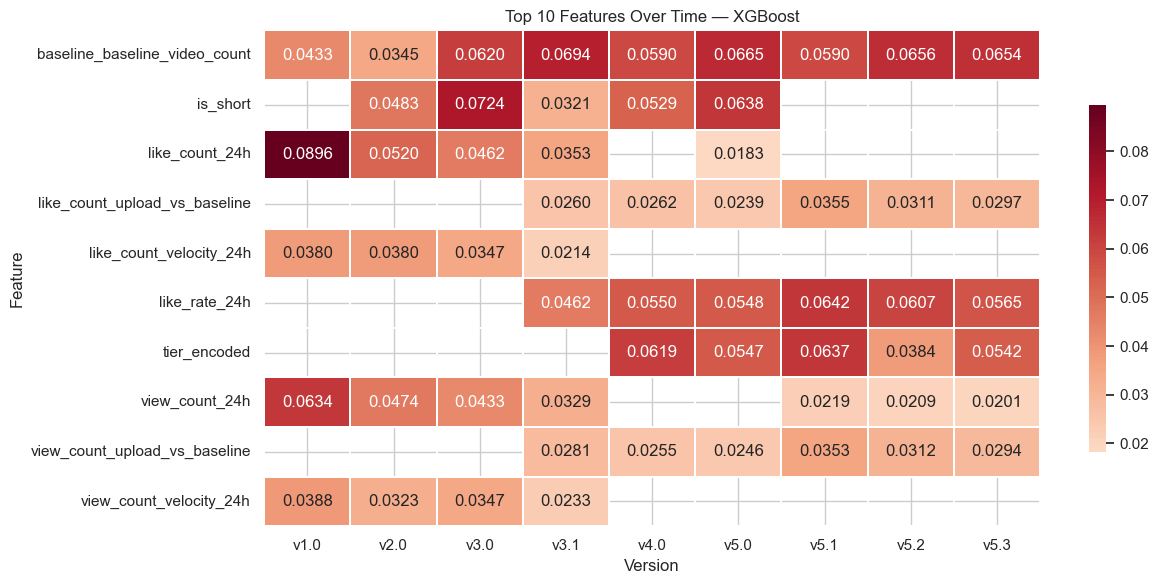

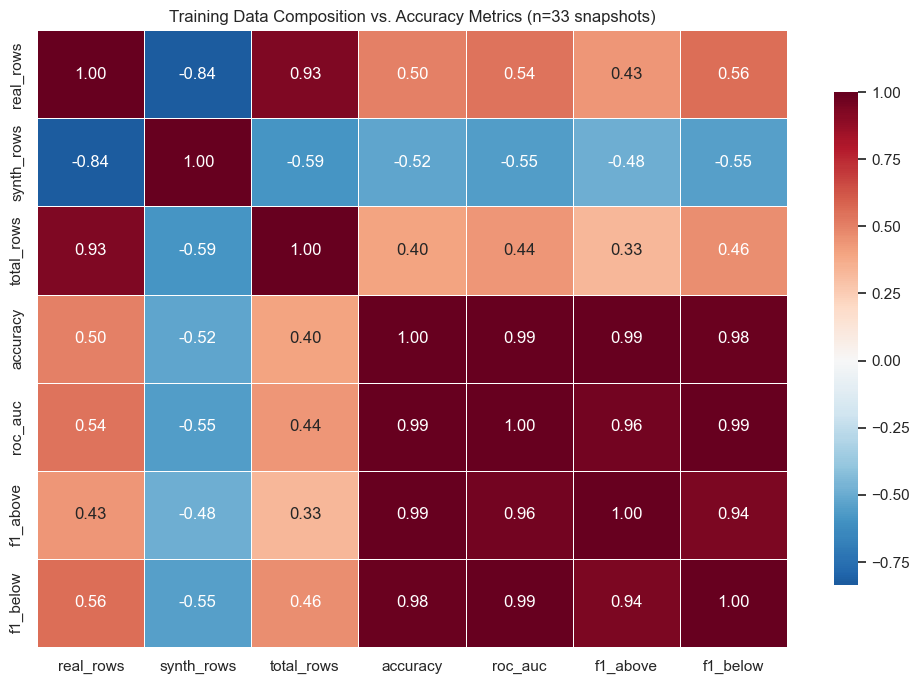

In [18]:
eda.plot_top_features_over_time(run, ModelType.XGB, save_figure_name=fig_path("features_over_time_xgb.png"))
eda.plot_data_composition_vs_accuracy(run, save_figure_name=fig_path("data_composition_accuracy.png"))

## Findings & next steps

<TODO(jelani): Add findings. Touch on below topics>

- **Model ranking** 
  - The persistent ~non-linear gap between the tree models and Logistic Regression
  - The core modeling finding of the project.
  - **segment blind spots** the audit surfaced (a vertical or tier where the
  leading model degrades), which feeds the final-selection decision.

**Next:** [04 · Hyperparameter tuning](./04_hyperparameter_tuning.ipynb)

## Persist version bump (GCS)

Runs only when `DRY_RUN=False`.

In [19]:
config.commit()

[dry_run] commit skipped — versions.json not written to GCS.
